<a href="https://colab.research.google.com/github/Geethika1205/SML/blob/main/plantdisease_ug1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()

Saving archive (10).zip to archive (10).zip


In [2]:
import zipfile

zip_path = "/content/archive (10).zip"
extract_path = "/content/PlantDoc"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [3]:
import os

dataset_path = "/content/PlantDoc"

for root, dirs, files in os.walk(dataset_path):
    print(root, len(files))

/content/PlantDoc 2
/content/PlantDoc/train 0
/content/PlantDoc/train/Apple_rust_leaf 96
/content/PlantDoc/train/Tomato_leaf 44
/content/PlantDoc/train/Tomato_Early_blight_leaf 79
/content/PlantDoc/train/Apple_leaf 79
/content/PlantDoc/train/Squash_Powdery_mildew_leaf 124
/content/PlantDoc/train/Corn_leaf_blight 182
/content/PlantDoc/train/Tomato_leaf_late_blight 101
/content/PlantDoc/train/Tomato_leaf_mosaic_virus 44
/content/PlantDoc/train/Raspberry_leaf 112
/content/PlantDoc/train/Potato_leaf_late_blight 200
/content/PlantDoc/train/Cherry_leaf 47
/content/PlantDoc/train/Corn_rust_leaf 107
/content/PlantDoc/train/Tomato_leaf_yellow_virus 223
/content/PlantDoc/train/Tomato_Septoria_leaf_spot 145
/content/PlantDoc/train/Corn_Gray_leaf_spot 63
/content/PlantDoc/train/grape_leaf 63
/content/PlantDoc/train/Tomato_two_spotted_spider_mites_leaf 2
/content/PlantDoc/train/Blueberry_leaf 106
/content/PlantDoc/train/Peach_leaf 103
/content/PlantDoc/train/Strawberry_leaf 88
/content/PlantDoc/tra

In [4]:
from PIL import Image
import os

folder = "/content/PlantDoc"
sample = None

for root, dirs, files in os.walk(folder):
    for f in files[:1]:
        sample = os.path.join(root, f)

img = Image.open(sample)
img.show()

In [5]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

img_size = 224
batch_size = 32

train_gen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

train_data = train_gen.flow_from_directory(
    dataset_path,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    subset="training"
)

val_data = train_gen.flow_from_directory(
    dataset_path,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    subset="validation"
)

Found 2338 images belonging to 2 classes.
Found 584 images belonging to 2 classes.


In [6]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models

# Base model
base_model = EfficientNetB0(
    include_top=False,
    weights='imagenet',
    input_shape=(224,224,3)
)

# Freeze early layers
for layer in base_model.layers:
    layer.trainable = False

# Attention block
def attention_block(x):
    attn = layers.Conv2D(1,1,activation='sigmoid')(x)
    return layers.multiply([x, attn])

x = base_model.output
x = attention_block(x)
x = layers.GlobalAveragePooling2D()(x)
output = layers.Dense(train_data.num_classes, activation='softmax')(x)

model = models.Model(base_model.input, output)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [7]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [8]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=20
)

Epoch 1/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 143s 2s/step - accuracy: 0.8905 - loss: 0.3369 - val_accuracy: 0.9144 - val_loss: 0.2980
Epoch 2/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 77s 1s/step - accuracy: 0.9136 - loss: 0.2981 - val_accuracy: 0.9144 - val_loss: 0.3001
Epoch 3/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 77s 1s/step - accuracy: 0.9136 - loss: 0.2943 - val_accuracy: 0.9144 - val_loss: 0.2922
Epoch 4/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 78s 1s/step - accuracy: 0.9136 - loss: 0.3001 - val_accuracy: 0.9144 - val_loss: 0.2922
Epoch 5/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 77s 1s/step - accuracy: 0.9136 - loss: 0.2977 - val_accuracy: 0.9144 - val_loss: 0.3013
Epoch 6/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 79s 1s/step - accuracy: 0.9136 - loss: 0.2986 - val_accuracy: 0.9144 - val_loss: 0.2927
Epoch 7/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 79s 1s/step - accuracy: 0.9136 - loss: 0.2974 - val_accuracy: 0.9144 - val_loss: 0.2963
Epoch 8/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 79s 1s/step - accuracy: 0.9136 - loss: 0.2993 - val_accuracy: 0.9144 - val_loss

In [9]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "best_model.h5",
    monitor='val_accuracy',
    save_best_only=True
)

In [10]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=30,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/30
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 799ms/step - accuracy: 0.9242 - loss: 0.2705

74/74 ━━━━━━━━━━━━━━━━━━━━ 80s 1s/step - accuracy: 0.9136 - loss: 0.2975 - val_accuracy: 0.9144 - val_loss: 0.2924
Epoch 2/30
74/74 ━━━━━━━━━━━━━━━━━━━━ 77s 1s/step - accuracy: 0.9136 - loss: 0.2974 - val_accuracy: 0.9144 - val_loss: 0.2943
Epoch 3/30
74/74 ━━━━━━━━━━━━━━━━━━━━ 77s 1s/step - accuracy: 0.9136 - loss: 0.2969 - val_accuracy: 0.9144 - val_loss: 0.3261
Epoch 4/30
74/74 ━━━━━━━━━━━━━━━━━━━━ 77s 1s/step - accuracy: 0.9136 - loss: 0.3046 - val_accuracy: 0.9144 - val_loss: 0.2952
Epoch 5/30
74/74 ━━━━━━━━━━━━━━━━━━━━ 77s 1s/step - accuracy: 0.9136 - loss: 0.2967 - val_accuracy: 0.9144 - val_loss: 0.2923
Epoch 6/30
74/74 ━━━━━━━━━━━━━━━━━━━━ 76s 1s/step - accuracy: 0.9136 - loss: 0.2968 - val_accuracy: 0.9144 - val_loss: 0.2929
Epoch 7/30
74/74 ━━━━━━━━━━━━━━━━━━━━ 80s 1s/step - accuracy: 0.9136 - loss: 0.2959 - val_accuracy: 0.9144 - val_loss: 0.3019
Epoch 8/30
74/74 ━━━━━━━━━━━━━━━━━━━━ 77s 1s/step - accuracy: 0.9136 - loss: 0.2999 - val_accuracy: 0.9144 - val_loss: 0.2921
Epo

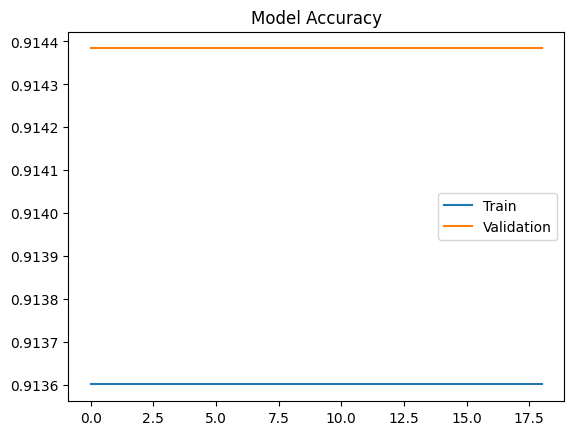

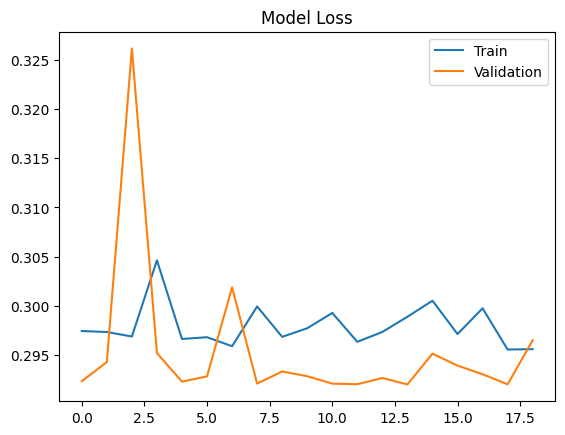

In [11]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.legend(['Train', 'Validation'])
plt.show()

In [12]:
val_loss, val_acc = model.evaluate(val_data)
print("Validation Accuracy:", val_acc)

19/19 ━━━━━━━━━━━━━━━━━━━━ 18s 926ms/step - accuracy: 0.9144 - loss: 0.2921
Validation Accuracy: 0.914383590221405


In [13]:
from tensorflow.keras import layers, models

def unet_model():
    inputs = layers.Input((224,224,3))

    # Encoder
    c1 = layers.Conv2D(32,3,activation='relu',padding='same')(inputs)
    p1 = layers.MaxPooling2D()(c1)

    c2 = layers.Conv2D(64,3,activation='relu',padding='same')(p1)

    # Decoder
    u1 = layers.UpSampling2D()(c2)
    concat = layers.Concatenate()([u1,c1])

    outputs = layers.Conv2D(1,1,activation='sigmoid')(concat)

    return models.Model(inputs, outputs)

seg_model = unet_model()

seg_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

seg_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 224, 224,  │        896 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 112, 112,  │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 112, 112,  │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d       │ (None, 224, 224,  │          0 │ conv2d_2[0][0]    │
│ (UpSampling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 224, 224,  │          0 │ up_sampling2d[0]… │
│ (Concatenate)       │ 96)               │            │ conv2d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 224, 224,  │         97 │ concatenate[0][0] │
│                     │ 1)                │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 19,489 (76.13 KB)

 Trainable params: 19,489 (76.13 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
import numpy as np

def disease_percentage(mask):
    disease_pixels = np.sum(mask > 0.5)
    total_pixels = mask.size
    return (disease_pixels / total_pixels) * 100

In [15]:
import cv2
import numpy as np
import os

def generate_mask(image_path):
    img = cv2.imread(image_path)
    img = cv2.resize(img, (224,224))

    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    # detect brown/yellow diseased areas
    lower = np.array([10,40,40])
    upper = np.array([35,255,255])

    mask = cv2.inRange(hsv, lower, upper)
    return mask

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving ChatGPT Image Mar 16, 2026, 11_02_50 PM.png to ChatGPT Image Mar 16, 2026, 11_02_50 PM.png


(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

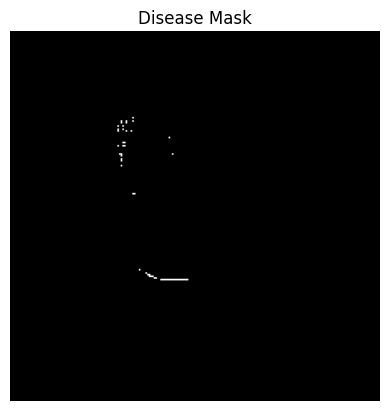

In [ ]:
import matplotlib.pyplot as plt

sample_img = "/content/ChatGPT Image Mar 16, 2026, 11_02_50 PM.png"  # change path
mask = generate_mask(sample_img)

plt.imshow(mask, cmap='gray')
plt.title("Disease Mask")
plt.axis("off")

In [ ]:
seg_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
def disease_percentage(mask):
    disease_pixels = np.sum(mask > 0)
    total_pixels = mask.size
    return (disease_pixels / total_pixels) * 100

In [ ]:
import numpy as np
import cv2
import os

image_paths = []
masks = []

dataset_path = "/content/PlantDoc"

for root, dirs, files in os.walk(dataset_path):
    for file in files:
        if file.endswith(('.jpg','.png','.jpeg','.webp')):
            path = os.path.join(root,file)
            img = cv2.imread(path)
            img = cv2.resize(img,(224,224))

            hsv = cv2.cvtColor(img,cv2.COLOR_BGR2HSV)
            lower = np.array([10,40,40])
            upper = np.array([35,255,255])
            mask = cv2.inRange(hsv,lower,upper)

            image_paths.append(img/255.0)
            masks.append(mask/255.0)

X = np.array(image_paths)
Y = np.array(masks)
Y = Y.reshape(-1,224,224,1)

In [ ]:
seg_model.fit(
    X, Y,
    batch_size=16,
    epochs=10,
    validation_split=0.2
)

In [16]:
pip install tensorflow keras opencv-python matplotlib scikit-learn

In [17]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import cv2
import matplotlib.pyplot as plt

In [18]:
IMG_SIZE = 224

def preprocess_image(img_path):
    img = cv2.imread(img_path)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = img / 255.0
    return img

In [19]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8,1.2]
)

In [20]:
base_model = tf.keras.applications.EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

x = layers.GlobalAveragePooling2D()(base_model.output)
x = layers.Dense(128, activation='relu')(x)
output = layers.Dense(num_classes, activation='softmax')(x)

classification_model = models.Model(inputs=base_model.input, outputs=output)

NameError: name 'num_classes' is not defined

In [21]:
num_classes = 4   # example (Healthy, Disease1, Disease2, Disease3)

In [22]:
num_classes = len(train_data.class_indices)
print(num_classes)

2


In [24]:
num_classes = len(train_data.class_indices)
print(num_classes)

2


In [26]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

In [29]:
data_dir = "/content/PlantDoc"

In [30]:
IMG_SIZE = 224
BATCH_SIZE = 32

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

train_data = datagen.flow_from_directory(
    data_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_data = datagen.flow_from_directory(
    data_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

Found 2338 images belonging to 2 classes.
Found 584 images belonging to 2 classes.


In [31]:
def attention_block(x, g):
    theta_x = layers.Conv2D(64, (1,1), padding='same')(x)
    phi_g = layers.Conv2D(64, (1,1), padding='same')(g)

    add = layers.Add()([theta_x, phi_g])
    act = layers.Activation('relu')(add)

    psi = layers.Conv2D(1, (1,1), activation='sigmoid')(act)
    return layers.Multiply()([x, psi])

In [32]:
def attention_unet(input_shape=(224,224,3)):
    inputs = layers.Input(input_shape)

    # Encoder
    c1 = layers.Conv2D(64,3,activation='relu',padding='same')(inputs)
    p1 = layers.MaxPooling2D()(c1)

    c2 = layers.Conv2D(128,3,activation='relu',padding='same')(p1)
    p2 = layers.MaxPooling2D()(c2)

    # Bottleneck
    bn = layers.Conv2D(256,3,activation='relu',padding='same')(p2)

    # Decoder + Attention
    u1 = layers.UpSampling2D()(bn)
    att1 = attention_block(c2, u1)
    u1 = layers.Concatenate()([u1, att1])

    u2 = layers.UpSampling2D()(u1)
    att2 = attention_block(c1, u2)
    u2 = layers.Concatenate()([u2, att2])

    outputs = layers.Conv2D(1,1,activation='sigmoid')(u2)

    return models.Model(inputs, outputs)

segmentation_model = attention_unet()

In [33]:
segmentation_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [34]:
import numpy as np

def calculate_severity(mask):
    diseased_pixels = np.sum(mask > 0.5)
    total_pixels = mask.size
    severity = (diseased_pixels / total_pixels) * 100
    return severity

In [35]:
def severity_level(severity):
    if severity < 25:
        return "Mild"
    elif severity < 50:
        return "Moderate"
    else:
        return "Severe"

In [36]:
def grad_cam(model, img):
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.layers[-3].output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img)
        loss = predictions[:, tf.argmax(predictions[0])]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

    heatmap = conv_outputs[0] * pooled_grads
    heatmap = tf.reduce_sum(heatmap, axis=-1)

    heatmap = np.maximum(heatmap, 0)
    heatmap /= np.max(heatmap)

    return heatmap

In [37]:
import cv2

def preprocess(img_path):
    img = cv2.imread(img_path)
    img = cv2.resize(img, (224,224))
    img = img / 255.0
    return np.expand_dims(img, axis=0)

In [39]:
from google.colab import files
uploaded = files.upload()

Saving plant leaf.jpg to plant leaf.jpg


In [40]:
img = preprocess("/content/plant leaf.jpg")

# Classification
pred = model.predict(img)

# Segmentation
mask = segmentation_model.predict(img)[0]

# Severity
severity = calculate_severity(mask)
level = severity_level(severity)

print("Severity:", severity)
print("Level:", level)

1/1 ━━━━━━━━━━━━━━━━━━━━ 14s 14s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Severity: 100.0
Level: Severe


In [41]:
class_names = list(train_data.class_indices.keys())
print(class_names)

['test', 'train']


In [42]:
import numpy as np

pred_class = np.argmax(pred)
disease_name = class_names[pred_class]

print("Predicted Disease:", disease_name)

Predicted Disease: train


In [44]:
import os
print(os.listdir('/content/plant leaf.jpg'))

NotADirectoryError: [Errno 20] Not a directory: '/content/plant leaf.jpg'

In [43]:
img = preprocess("/content/your_image.jpg")

pred = model.predict(img)
mask = segmentation_model.predict(img)[0]

# Disease name
class_names = list(train_data.class_indices.keys())
pred_class = np.argmax(pred)
disease_name = class_names[pred_class]

# Severity
severity = calculate_severity(mask)
level = severity_level(severity)

print("Disease:", disease_name)
print("Severity: {:.2f}%".format(severity))
print("Condition:", level)

error: OpenCV(4.13.0) /io/opencv/modules/imgproc/src/resize.cpp:4208: error: (-215:Assertion failed) !ssize.empty() in function 'resize'


In [45]:
import os
print(os.listdir('/content'))

['.config', 'archive (10).zip', 'PlantDoc', 'plant leaf.jpg', 'best_model.h5', 'sample_data']


In [46]:
img = preprocess("/content/plant leaf.jpg")

In [47]:
img = preprocess("/content/plant leaf.jpg")

if img is not None:

    pred = model.predict(img)
    mask = segmentation_model.predict(img)[0]

    class_names = list(train_data.class_indices.keys())
    pred_class = np.argmax(pred)
    disease_name = class_names[pred_class]

    severity = np.mean(mask) * 100

    if severity < 25:
        level = "Mild"
    elif severity < 50:
        level = "Moderate"
    else:
        level = "Severe"

    print("🌿 Disease:", disease_name)
    print("📊 Severity: {:.2f}%".format(severity))
    print("⚠️ Condition:", level)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
🌿 Disease: train
📊 Severity: 52.07%
⚠️ Condition: Severe


In [48]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [49]:
y_pred = model.predict(val_data)
y_pred_classes = np.argmax(y_pred, axis=1)

y_true = val_data.classes

19/19 ━━━━━━━━━━━━━━━━━━━━ 39s 2s/step


In [50]:
cm = confusion_matrix(y_true, y_pred_classes)
print(cm)

[[  0  50]
 [  0 534]]


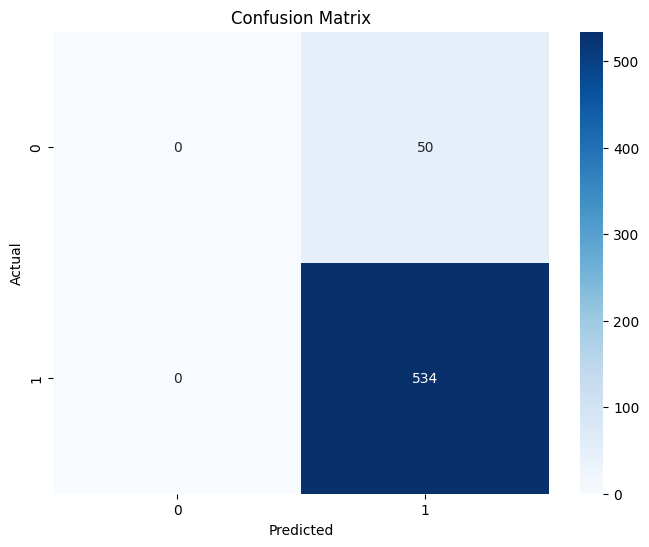

In [51]:
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [52]:
class_names = list(val_data.class_indices.keys())

report = classification_report(y_true, y_pred_classes, target_names=class_names)
print(report)

              precision    recall  f1-score   support

        test       0.00      0.00      0.00        50
       train       0.91      1.00      0.96       534

    accuracy                           0.91       584
   macro avg       0.46      0.50      0.48       584
weighted avg       0.84      0.91      0.87       584



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [53]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_true, y_pred_classes, average='weighted')
recall = recall_score(y_true, y_pred_classes, average='weighted')
f1 = f1_score(y_true, y_pred_classes, average='weighted')

print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Precision: 0.8360972978044662
Recall: 0.9143835616438356
F1 Score: 0.8734898424289951


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [54]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_data.classes),
    y=train_data.classes
)

class_weights = dict(enumerate(class_weights))

print(class_weights)

{0: np.float64(5.787128712871287), 1: np.float64(0.5472846441947565)}


In [55]:
model.fit(
    train_data,
    validation_data=val_data,
    epochs=5,
    class_weight=class_weights
)

Epoch 1/5
74/74 ━━━━━━━━━━━━━━━━━━━━ 111s 1s/step - accuracy: 0.5261 - loss: 0.7202 - val_accuracy: 0.9144 - val_loss: 0.6633
Epoch 2/5
74/74 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 0.8918 - loss: 0.6939 - val_accuracy: 0.9144 - val_loss: 0.6769
Epoch 3/5
74/74 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 0.8097 - loss: 0.6937 - val_accuracy: 0.9144 - val_loss: 0.6711
Epoch 4/5
74/74 ━━━━━━━━━━━━━━━━━━━━ 80s 1s/step - accuracy: 0.8978 - loss: 0.6933 - val_accuracy: 0.9144 - val_loss: 0.6756
Epoch 5/5
74/74 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 0.4256 - loss: 0.6936 - val_accuracy: 0.0856 - val_loss: 0.7032


In [56]:
model.fit(
    train_data,
    validation_data=val_data,
    epochs=15   # 🔥 increase from 5 → 15
)

Epoch 1/15
74/74 ━━━━━━━━━━━━━━━━━━━━ 84s 1s/step - accuracy: 0.8627 - loss: 0.6142 - val_accuracy: 0.9144 - val_loss: 0.5466
Epoch 2/15
74/74 ━━━━━━━━━━━━━━━━━━━━ 83s 1s/step - accuracy: 0.9136 - loss: 0.3634 - val_accuracy: 0.9144 - val_loss: 0.2963
Epoch 3/15
74/74 ━━━━━━━━━━━━━━━━━━━━ 80s 1s/step - accuracy: 0.9136 - loss: 0.3025 - val_accuracy: 0.9144 - val_loss: 0.2929
Epoch 4/15
74/74 ━━━━━━━━━━━━━━━━━━━━ 80s 1s/step - accuracy: 0.9136 - loss: 0.2992 - val_accuracy: 0.9144 - val_loss: 0.2937
Epoch 5/15
74/74 ━━━━━━━━━━━━━━━━━━━━ 79s 1s/step - accuracy: 0.9136 - loss: 0.2988 - val_accuracy: 0.9144 - val_loss: 0.2921
Epoch 6/15
74/74 ━━━━━━━━━━━━━━━━━━━━ 79s 1s/step - accuracy: 0.9136 - loss: 0.2965 - val_accuracy: 0.9144 - val_loss: 0.2924
Epoch 7/15
74/74 ━━━━━━━━━━━━━━━━━━━━ 79s 1s/step - accuracy: 0.9136 - loss: 0.2980 - val_accuracy: 0.9144 - val_loss: 0.2920
Epoch 8/15
74/74 ━━━━━━━━━━━━━━━━━━━━ 77s 1s/step - accuracy: 0.9136 - loss: 0.2985 - val_accuracy: 0.9144 - val_loss:

In [57]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_data.classes),
    y=train_data.classes
)

class_weights = dict(enumerate(class_weights))

model.fit(
    train_data,
    validation_data=val_data,
    epochs=15,
    class_weight=class_weights
)

Epoch 1/15
74/74 ━━━━━━━━━━━━━━━━━━━━ 83s 1s/step - accuracy: 0.5030 - loss: 0.7676 - val_accuracy: 0.0856 - val_loss: 0.9714
Epoch 2/15
74/74 ━━━━━━━━━━━━━━━━━━━━ 81s 1s/step - accuracy: 0.5834 - loss: 0.7046 - val_accuracy: 0.9144 - val_loss: 0.6345
Epoch 3/15
74/74 ━━━━━━━━━━━━━━━━━━━━ 79s 1s/step - accuracy: 0.6108 - loss: 0.7022 - val_accuracy: 0.9144 - val_loss: 0.6685
Epoch 4/15
74/74 ━━━━━━━━━━━━━━━━━━━━ 79s 1s/step - accuracy: 0.4149 - loss: 0.6969 - val_accuracy: 0.9144 - val_loss: 0.6617
Epoch 5/15
74/74 ━━━━━━━━━━━━━━━━━━━━ 78s 1s/step - accuracy: 0.5796 - loss: 0.7006 - val_accuracy: 0.9144 - val_loss: 0.6105
Epoch 6/15
74/74 ━━━━━━━━━━━━━━━━━━━━ 78s 1s/step - accuracy: 0.5646 - loss: 0.7080 - val_accuracy: 0.0856 - val_loss: 0.8090
Epoch 7/15
74/74 ━━━━━━━━━━━━━━━━━━━━ 78s 1s/step - accuracy: 0.6099 - loss: 0.7028 - val_accuracy: 0.9144 - val_loss: 0.6619
Epoch 8/15
74/74 ━━━━━━━━━━━━━━━━━━━━ 78s 1s/step - accuracy: 0.5252 - loss: 0.7007 - val_accuracy: 0.9144 - val_loss:

In [58]:
print(history.history['accuracy'])
print(history.history['val_accuracy'])

[0.9136013984680176, 0.9136013984680176, 0.9136013984680176, 0.9136013984680176, 0.9136013984680176, 0.9136013984680176, 0.9136013984680176, 0.9136013984680176, 0.9136013984680176, 0.9136013984680176, 0.9136013984680176, 0.9136013984680176, 0.9136013984680176, 0.9136013984680176, 0.9136013984680176, 0.9136013984680176, 0.9136013984680176, 0.9136013984680176, 0.9136013984680176]
[0.914383590221405, 0.914383590221405, 0.914383590221405, 0.914383590221405, 0.914383590221405, 0.914383590221405, 0.914383590221405, 0.914383590221405, 0.914383590221405, 0.914383590221405, 0.914383590221405, 0.914383590221405, 0.914383590221405, 0.914383590221405, 0.914383590221405, 0.914383590221405, 0.914383590221405, 0.914383590221405, 0.914383590221405]


In [59]:
y_pred = model.predict(val_data)
y_pred_classes = np.argmax(y_pred, axis=1)

from sklearn.metrics import confusion_matrix
cm = confusion_matrix(val_data.classes, y_pred_classes)
print(cm)

19/19 ━━━━━━━━━━━━━━━━━━━━ 19s 954ms/step
[[ 50   0]
 [534   0]]


In [60]:
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=30,
    zoom_range=0.3,
    horizontal_flip=True,
    brightness_range=[0.6,1.4]
)

In [61]:
y_pred = model.predict(val_data)
y_pred_classes = np.argmax(y_pred, axis=1)

from sklearn.metrics import confusion_matrix
cm = confusion_matrix(val_data.classes, y_pred_classes)
print(cm)

19/19 ━━━━━━━━━━━━━━━━━━━━ 19s 952ms/step
[[ 50   0]
 [534   0]]
